In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import beta
import emcee 
import corner as cp
import sbi
from sbi.inference import NPE, simulate_for_sbi
from sbi import analysis as analysis
from sbi import utils as utils
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import math
import os
import torch
import csv
from sbi.analysis import pairplot
import pandas as pd

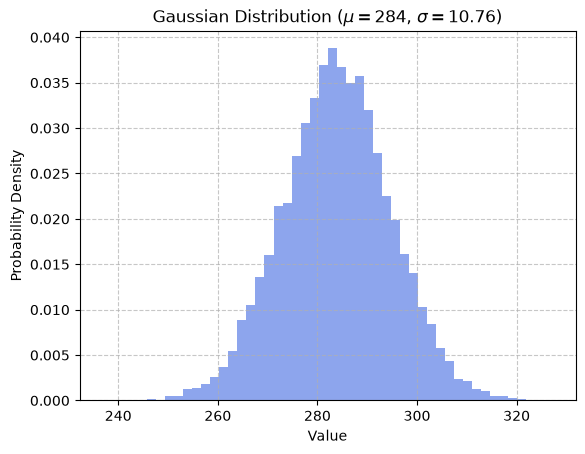

In [7]:
#set up a random gaussian
rng = np.random.default_rng(seed=42)

mu = 284  
sigma = 10.76   
N = 10000 
samples = rng.normal(loc=mu, scale=sigma, size=N)

plt.hist(samples, bins=50, density=True, alpha=0.6, color='royalblue')
plt.title(f"Gaussian Distribution ($\mu={mu}$, $\sigma={sigma}$)")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


(array([2.91776425e-04, 2.91776425e-04, 3.89035234e-04, 4.86294042e-04,
        1.84791736e-03, 2.43147021e-03, 2.23695259e-03, 3.69583472e-03,
        5.05745804e-03, 6.71085778e-03, 8.94781037e-03, 1.27409039e-02,
        1.39080096e-02, 2.05216086e-02, 2.41201845e-02, 3.41378418e-02,
        3.25817008e-02, 3.46241358e-02, 4.53226047e-02, 4.95047335e-02,
        5.01855451e-02, 5.24224977e-02, 5.68964029e-02, 5.49512268e-02,
        6.01059436e-02, 5.78689910e-02, 5.12553920e-02, 4.94074747e-02,
        4.10432172e-02, 3.81254529e-02, 2.87886073e-02, 3.08310423e-02,
        2.40229257e-02, 1.85764324e-02, 1.33244568e-02, 1.18655746e-02,
        8.26699872e-03, 7.68344587e-03, 5.25197565e-03, 3.01502306e-03,
        2.62598783e-03, 1.84791736e-03, 1.36162332e-03, 1.26436451e-03,
        6.80811659e-04, 2.91776425e-04, 3.89035234e-04, 2.91776425e-04,
        0.00000000e+00, 9.72588084e-05]),
 array([279.81948885, 280.84767336, 281.87585787, 282.90404237,
        283.93222688, 284.9604

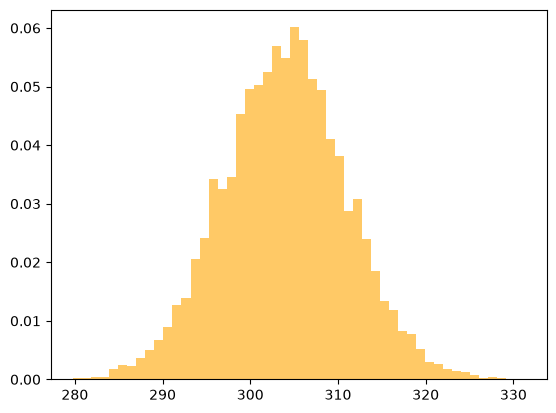

In [ ]:
# and prior
mu_guess = 304
sigma_guess = 7
prior = np.random.normal(loc=mu_guess, scale=sigma_guess, size=N)
plt.hist(prior, bins=50, density=True, alpha=0.6, color='orange')

In [20]:
n_points = N  

def simulator(theta, x, noise):
    mu, sigma = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + sim_noise
    
    obs = np.concatenate([y_sim, x, noise])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

n_simulations = 2000
samples = samples.to_numpy()
theta_train = samples.sample((n_simulations,))
x_train = torch.stack([simulator(theta) for theta in theta_train])

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

AttributeError: 'numpy.ndarray' object has no attribute 'to_numpy'

In [ ]:

prior = BoxUniform(
    low=torch.tensor([250.0, 1.0]),
    high=torch.tensor([320.0, 30.0]),)

n_points = 100  

def simulator(theta):
    mu, sigma = theta[0], theta[1]
    data = mu + sigma * torch.randn(n_points)
    return torch.stack([data.mean(), data.std()])

n_simulations = 2000
theta_train = prior.sample((n_simulations,))
x_train = torch.stack([simulator(t) for t in theta_train])

inference = NPE(prior=prior)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

obs = torch.tensor(observed, dtype=torch.float32)
x_o = torch.stack([obs.mean(), obs.std()])
post_samples = posterior.sample((5000,), x=x_o)

NameError: name 'BoxUniform' is not defined